## PENDIENTE:
- Meterle más magia económica al feature selection (explicación).
- Serie diferenciada ----> Normalizarla (en dólares, o log).
- Revisar explicación de la ttf de la st del merval.

#### A. Librerías, variables, funciones y lectura de datos.

In [43]:
#1. Importo librerías.
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import holidays
from scipy import signal

In [44]:
#2. Lectura de datos.
series_temporales = pd.read_csv("../inputs/dataset_v2.csv")
diccionario = pd.read_excel("../inputs/diccionario.xlsx",sheet_name="metadata")

#### B. EDA.

In [45]:
#1. Columnas y variables.
print("Tenemos {} columnas. Estas son: {}".format(series_temporales.shape[1],series_temporales.columns))

Tenemos 37 columnas. Estas son: Index(['fecha', 'merval_apertura', 'merval_maximo', 'merval_minimo',
       'merval_cierre', 'embi_spread_arg', 'embi_spreads_brz',
       'embi_spread_global', 'emae_original', 'emae_desestacionalizado',
       'emae_tendencia_ciclo', 'tc_minorista', 'tc_mayorista', 'rrii', 'tamar',
       'badlar', 'tm20', 'tasa_prestamos_personales', 'tasa_pf_pesos',
       'tasa_pf_dolares', 'base_monetaria', 'circulacion_monetaria',
       'dep_ccorrientes', 'dep_cahorro', 'dep_plazo', 'dep_plazo_fijo', 'm1',
       'm2', 'm2_transaccional', 'dep_dolar_priv_ars',
       'prestamos_privados_pesos_ars', 'prestamos_privados_dolares_ars',
       'prestamos_privados_ars', 'inflacion', 'rem', 'cer', 'uva'],
      dtype='object')


In [46]:
#2. Información general de las variables.
series_temporales.info() 

# Tenemos series temporales con datos nulos......

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4487 entries, 0 to 4486
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   fecha                           3599 non-null   object 
 1   merval_apertura                 3599 non-null   float64
 2   merval_maximo                   3599 non-null   float64
 3   merval_minimo                   3599 non-null   float64
 4   merval_cierre                   3599 non-null   float64
 5   embi_spread_arg                 3468 non-null   float64
 6   embi_spreads_brz                3468 non-null   float64
 7   embi_spread_global              3468 non-null   float64
 8   emae_original                   3576 non-null   float64
 9   emae_desestacionalizado         3576 non-null   float64
 10  emae_tendencia_ciclo            3576 non-null   float64
 11  tc_minorista                    3577 non-null   float64
 12  tc_mayorista                    35

In [47]:
#3. Convertimos tipo de datos de la fecha a datetime y la ordenamos por dicha variable.
series_temporales["fecha"] = pd.to_datetime(series_temporales["fecha"])
series_temporales = series_temporales.sort_values("fecha")

In [48]:
#4. Borramos filas enteras con NA.
series_temporales.dropna(how='all', inplace=True)

In [49]:
#5. Entendemos las fechas de inicio y fin de la Serie temporal
inicio = series_temporales["fecha"].sort_values(ascending=True).iloc[0]
fin = series_temporales["fecha"].sort_values(ascending=False).iloc[0]

print(f"Las series temporales son algunas diarias, y otras mensuales, yendo desde {inicio} a {fin}.")

Las series temporales son algunas diarias, y otras mensuales, yendo desde 2011-01-03 00:00:00 a 2025-09-30 00:00:00.


In [50]:
#6. Nos quedamos con la información de 2023 hasta hoy para evitar la pandemia.
series_temporales = series_temporales[series_temporales["fecha"] >= "2023-01-01"]

In [51]:
#7. Tiene fechas repetidas?
print("Fechas unicas: {}".format(series_temporales["fecha"].nunique()))
print("Cantidad de filas totales: {}".format(series_temporales.shape[0]))

Fechas unicas: 682
Cantidad de filas totales: 682


In [52]:
#8. Entre el inicio y fin hay 682 fechas?
inicio = series_temporales["fecha"].sort_values(ascending=True).iloc[0]
fin = series_temporales["fecha"].sort_values(ascending=False).iloc[0]

print("Tenemos una apertura de fechas de {} días".format(fin - inicio))
print("Debería cubrir {} días".format(series_temporales.shape[0]))

Tenemos una apertura de fechas de 1002 days 00:00:00 días
Debería cubrir 682 días


In [53]:
#9. Que fechas faltan?
#a. Análisis general.
inicio = series_temporales["fecha"].min()
fin = series_temporales["fecha"].max()

rango_completo = pd.date_range(start=inicio, end=fin, freq='D')

fechas_reales = series_temporales["fecha"].unique()

fechas_faltantes = rango_completo.difference(fechas_reales)

#print("Cantidad de fechas faltantes:", len(fechas_faltantes))
#print("Fechas faltantes:")
#print(fechas_faltantes)
#print("-------------------------------------------------------------------")
#b. Análisis de días de la semana.
faltantes_df = pd.DataFrame(fechas_faltantes, columns=["fecha"])
faltantes_df["dia_semana"] = faltantes_df["fecha"].dt.day_name(locale="es_ES")
faltantes_laborales = faltantes_df[
    ~faltantes_df["dia_semana"].isin(["Sábado", "Domingo"])
]

#print("Cantidad de fechas faltantes en días hábiles:", len(faltantes_laborales))
#print(faltantes_laborales)
#print("-------------------------------------------------------------------")

#c. Excluimos los feriados nacionales.
feriados_ar = holidays.AR(years=range(inicio.year, fin.year + 1))
faltantes_laborales["es_feriado"] = faltantes_laborales["fecha"].isin(feriados_ar)
faltantes_no_fds_ni_feriados = faltantes_laborales[~(faltantes_laborales["es_feriado"])]

#print("Cantidad de fechas faltantes que no son fin de semana ni feriados:", len(faltantes_no_fds_ni_feriados))
#print(faltantes_no_fds_ni_feriados)

#d. Fueron feriados bursátiles?
#2023-11-06      Lunes       -----> No operó (cierre igual).
#2024-01-12     Viernes      -----> 12.01.2024	1.033.122,75	1.043.924,00	1.060.576,75	1.019.806,19		-1.03%
#2024-01-15      Lunes       -----> 1.038.358,25	1.033.122,75	1.044.896,56	1.031.711,13		+0.51%
#2024-12-31     Martes       -----> No operó.
#2025-09-08      Lunes       -----> 08.09.2025	1.732.923,75	1.997.624,38	1.997.624,38	1.723.049,63		-13.25%.

#e. Completo con los datos faltantes solamente para la serie de Merval (es la variable objetivo). Las demás vamos a completar los Nulos.
#i. Datos recolectados.
datos_faltantes = [
    # fecha, cierre, apertura, max, min
    #("2023-11-06", np.nan, np.nan, np.nan, np.nan),  # No operó
    ("2024-01-12", 1033122.75, 1043924.00, 1060576.75, 1019806.19),
    ("2024-01-15", 1038358.25, 1033122.75, 1044896.56, 1031711.13),
    #("2024-12-31", np.nan, np.nan, np.nan, np.nan),  # No operó
    ("2025-09-08", 1732923.75, 1997624.38, 1997624.38, 1723049.63)
]

#ii. Creamos un DataFrame temporal.
df_faltantes = pd.DataFrame(datos_faltantes, columns=[
    "fecha", "merval_cierre", "merval_apertura", "merval_maximo", "merval_minimo"
])

#d. Convertimos la columna fecha a datetime.
df_faltantes["fecha"] = pd.to_datetime(df_faltantes["fecha"])

#e. Creamos las demás columnas con NaN
otras_columnas = [col for col in series_temporales.columns if col not in df_faltantes.columns]
for col in otras_columnas:
    df_faltantes[col] = np.nan

#f. Reordenamos las columnas igual que el df original.
df_faltantes = df_faltantes[series_temporales.columns]

#g. Concatenamos.
series_temporales = pd.concat([series_temporales, df_faltantes], ignore_index=True)

#h. Ordenamos por fecha.
series_temporales = series_temporales.sort_values("fecha").reset_index(drop=True)

C:\Users\i_link\AppData\Local\Temp\ipykernel_22344\1693815642.py:29: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  faltantes_laborales["es_feriado"] = faltantes_laborales["fecha"].isin(feriados_ar)
C:\Users\i_link\AppData\Local\Temp\ipykernel_22344\1693815642.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  faltantes_laborales["es_feriado"] = faltantes_laborales["fecha"].isin(feriados_ar)


In [54]:
#10. Analisis estadísticos descriptivos básicos de las series temporales.
series_temporales.describe()

,fecha,merval_apertura,merval_maximo,merval_minimo,merval_cierre,embi_spread_arg,embi_spreads_brz,embi_spread_global,emae_original,emae_desestacionalizado,...,m2,m2_transaccional,dep_dolar_priv_ars,prestamos_privados_pesos_ars,prestamos_privados_dolares_ars,prestamos_privados_ars,inflacion,rem,cer,uva
count,685,6.850000e+02,6.850000e+02,6.850000e+02,6.850000e+02,640.000000,640.000000,640.000000,659.000000,659.000000,...,6.660000e+02,6.660000e+02,6.660000e+02,6.670000e+02,6.670000e+02,6.670000e+02,682.000000,682.000000,6.820000e+02,682.000000
mean,2024-05-19 19:47:44.233576448,1.353092e+06,1.379440e+06,1.331017e+06,1.354765e+06,1506.725614,218.239244,329.821909,148.554118,148.200228,...,4.286579e+07,2.864640e+07,7.056447e+07,3.335018e+07,7.523042e+06,4.087322e+07,6.647801,92.077419,3.427130e+06,863.340308
min,2023-01-02 00:00:00,1.983605e+05,2.014390e+05,1.971830e+05,1.983605e+05,558.677000,177.877000,252.671000,133.637222,140.975690,...,1.195411e+07,8.749524e+06,1.853549e+07,6.731077e+06,6.179090e+05,7.349306e+06,1.500000,20.800000,7.372530e+05,185.320000
25%,2023-09-12 00:00:00,5.766761e+05,5.864570e+05,5.631250e+05,5.791500e+05,767.273250,203.214500,297.201000,146.294126,146.262475,...,1.959452e+07,1.299355e+07,3.211712e+07,1.150116e+07,1.319397e+06,1.283809e+07,2.700000,25.900000,1.257443e+06,315.987500
50%,2024-05-22 00:00:00,1.473463e+06,1.494250e+06,1.452160e+06,1.477796e+06,1493.004500,213.678500,329.285000,148.432243,149.059374,...,4.219687e+07,2.538839e+07,6.525406e+07,2.220329e+07,5.542188e+06,2.767160e+07,4.600000,68.900000,3.804944e+06,958.265000
75%,2025-01-23 00:00:00,2.064099e+06,2.093480e+06,2.031090e+06,2.064025e+06,2032.774750,228.875750,357.350250,152.557032,151.031014,...,6.351169e+07,4.475086e+07,1.093843e+08,5.463106e+07,1.263543e+07,6.726649e+07,8.400000,154.900000,5.249510e+06,1324.535000
max,2025-09-30 00:00:00,2.829730e+06,2.867770e+06,2.782480e+06,2.829730e+06,2726.046000,277.665000,420.845000,164.762238,153.187431,...,8.101978e+07,5.786772e+07,1.469218e+08,8.165001e+07,2.717522e+07,1.072174e+08,25.500000,226.700000,6.337826e+06,1599.500000
std,NaN,7.735390e+05,7.862351e+05,7.599226e+05,7.720572e+05,651.831477,19.885983,39.120738,6.434760,3.321257,...,2.233860e+07,1.555385e+07,3.977701e+07,2.448687e+07,7.316613e+06,3.168881e+07,5.412188,68.944352,1.973958e+06,498.361513


#### C. Selección de variables (Feature Selection).

##### 1. Análisis estadístico.

                                merval_apertura  merval_maximo  merval_minimo  \
merval_apertura                        1.000000       0.999180       0.999131   
merval_maximo                          0.999180       1.000000       0.999025   
merval_minimo                          0.999131       0.999025       1.000000   
merval_cierre                          0.998284       0.999265       0.999316   
embi_spread_arg                       -0.937879      -0.937984      -0.938647   
embi_spreads_brz                      -0.350206      -0.351666      -0.353639   
embi_spread_global                    -0.787379      -0.788298      -0.789251   
emae_original                          0.205937       0.204585       0.206179   
emae_desestacionalizado                0.402445       0.401104       0.398701   
emae_tendencia_ciclo                   0.496740       0.494615       0.493387   
tc_minorista                           0.918582       0.918054       0.919548   
tc_mayorista                

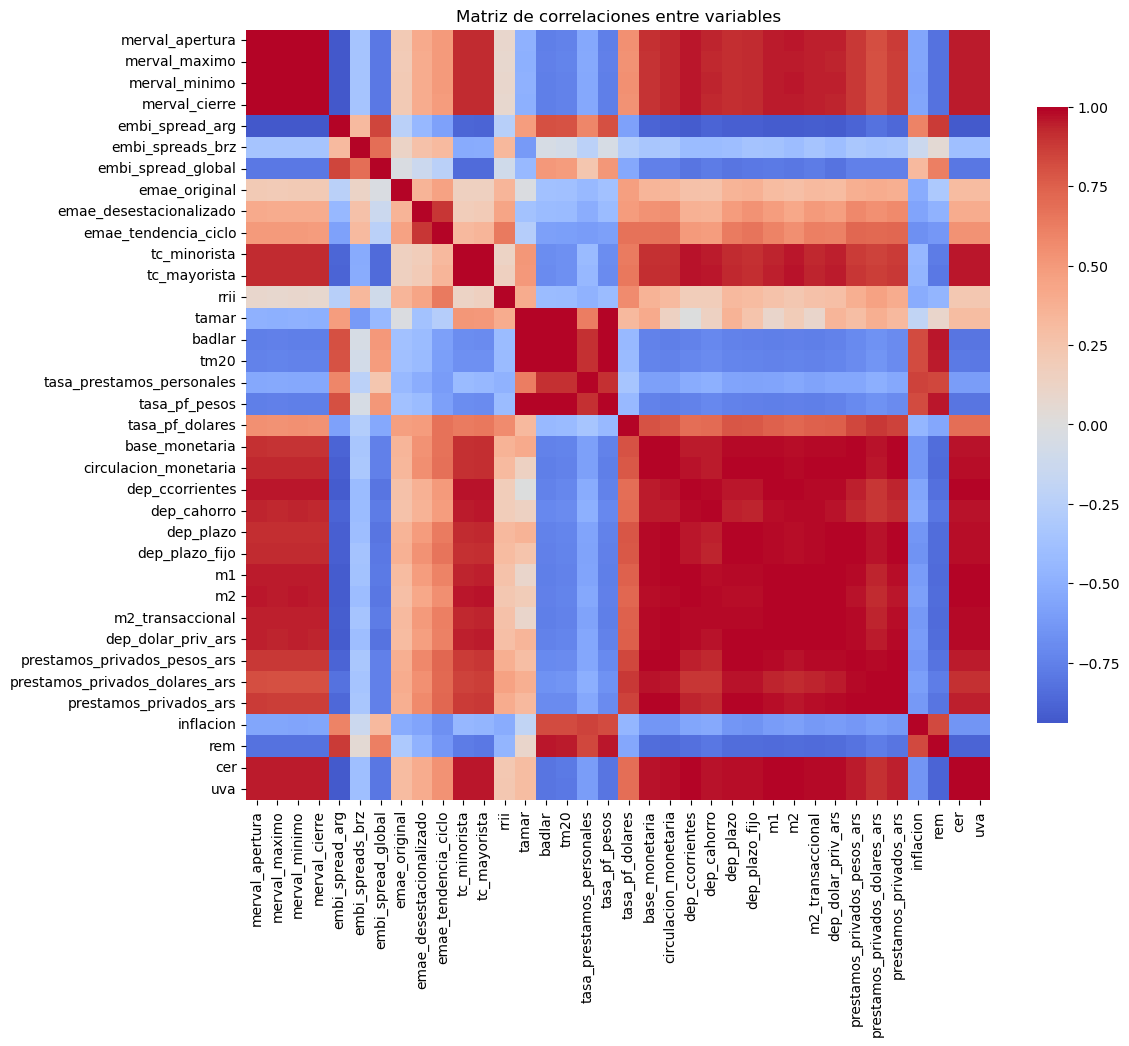

In [58]:
#1. Análisis estadístico previo.
#a. Eliminamos la columna 'fecha' y calculamos la matriz de correlaciones.
corr_matrix = series_temporales.drop(columns=['fecha']).corr()

#b. Mostramos la matriz.
print(corr_matrix)

#c. visualizamos con un mapa de calor.
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, cbar_kws={'shrink': .8})
plt.title('Matriz de correlaciones entre variables')
plt.show()

##### 2. Análisis conceptual.

In [ ]:
#1. Con el único precio del Merval que me voy a quedar es con el de apertura, ya que sería Data Leakeage utilizar las demás.
series_temporales.drop(["merval_maximo","merval_minimo","merval_cierre"],axis=1,inplace=True)

In [ ]:
#2. Mercado financiero local e internacional.
# embi_spread_arg → mide riesgo país argentino, impacta directamente en valuaciones y flujos hacia equity local.
# embi_spreads_brz → referencia regional, ayuda a distinguir si el movimiento es idiosincrático argentino o regional.
# embi_spread_global → mide apetito global por riesgo; buen predictor en contextos de estrés global.

In [ ]:
#3. Tipo de cambio y reservas.
# tc_mayorista / tc_minorista → el tipo de cambio suele anticipar o acompañar movimientos del equity argentino (devaluación = caída en USD, pero subas nominales en ARS).
# rrii (reservas internacionales) → indicador de fortaleza macro, política monetaria y confianza.

In [ ]:
#4. Tasas e instrumentos financieros ----> reflejan el costo del dinero. Cambios en tasas reales afectan valuación de acciones (vía DCF y flujos futuros).
# Vamos a elegir solamente BADLAR para evitar multicolinealidad.
series_temporales.drop(["tamar","tm20", "tasa_pf_pesos", "tasa_pf_dolares","tasa_prestamos_personales"],axis=1,inplace=True)

In [ ]:
#5. Variables monetarias.
# base_monetaria, m1, m2_transaccional → reflejan liquidez del sistema. En Argentina, expansión monetaria suele correlacionar con subas nominales del Merval (no reales).
# Se descartan dep_ccorrientes, dep_cahorro, dep_plazo, dep_plazo_fijo, dep_dolar_priv_ars ya que todas son componentes de M1 o M2. Y m2 ya que está muy correlacionada con m2_transaccional.
series_temporales.drop(["dep_ccorrientes", "dep_cahorro", "dep_plazo", "dep_plazo_fijo", "dep_dolar_priv_ars","m2"],axis=1,inplace=True)

In [ ]:
#6. Actividad real.
# emae_tendencia_ciclo → indicador del ciclo económico real argentino.
# Se descartan emae_original y emae_desestacionalizado para evitar colinealidad. 
# Además, emae_tendencia_ciclo captura la tendencia de largo plazo y el ciclo económico subyacente, sin el ruido diario/mensual. 
# Es más estable y predictivo para un índice bursátil que responde a expectativas macro, no a movimientos mensuales aislados.
series_temporales.drop(["emae_original","emae_desestacionalizado"],axis=1,inplace=True)

In [ ]:
#7. Expectativas e inflación.
# inflación: importante para variables nominales (Merval en ARS).
# REM: anticipa expectativas.
# CER/ UVA: capturan indexación y costo de financiamiento ----> Vamos a descatarlas porque aportan información derivada de inflacion (el efecto conceptual ya lo estamos capturando).
series_temporales.drop(["cer","uva"],axis=1,inplace=True)

In [ ]:
#8. Préstamos.
# Me quedo solamente con prestamos_privados_pesos_ars.
# Se descarta prestamos_privados_dolares_ars y prestamos_privados_ars porque están muy correlacionados.
series_temporales.drop(["prestamos_privados_dolares_ars","prestamos_privados_ars"],axis=1,inplace=True)

In [59]:
print("En total me quedo con {} columnas regresoras para predecir el precio de apertura del Merval.".format(len(series_temporales.columns)-2))

En total me quedo con 35 columnas regresoras para predecir el precio de apertura del Merval.


#### D. Planteo de hipótesis previo a análisis de variables.

1️⃣ Riesgo y spreads

Variables: embi_spread_arg, embi_spreads_brz, embi_spread_global

Hipótesis:

embi_spread_arg ↑ → mayor percepción de riesgo país → menor apetito por acciones argentinas → Merval apertura ↓

embi_spreads_brz ↑ → si Brasil (referencia regional) se vuelve más riesgoso, puede haber salida de capitales regionales → Merval apertura ↓

embi_spread_global ↑ → riesgo global aumenta → inversores buscan refugio → salida de mercados emergentes → Merval apertura ↓

💡 Nota: podrían aparecer efectos no lineales en momentos de pánico o alta volatilidad.

2️⃣ Actividad económica

Variable: emae_tendencia_ciclo

Hipótesis:

emae_tendencia_ciclo ↑ → economía en expansión → empresas reportan mejores resultados → mayor confianza → Merval apertura ↑

Se espera retraso temporal: los cambios en el ciclo económico pueden anticipar movimientos de mercado, pero con rezagos de 1–3 meses.

3️⃣ Tipo de cambio y reservas

Variables: tc_minorista, tc_mayorista, rrii

Hipótesis:

tc_mayorista ↑ o tc_minorista ↑ → devaluación → el Merval medido en ARS puede subir nominalmente, pero puede indicar riesgo macro → efecto ambivalente sobre el precio de apertura.

rrii ↑ → más reservas → confianza macro → Merval apertura ↑

💡 Nota: conviene usar rezagos del tipo de cambio y reservas para que el modelo capture causalidad y no solo correlación diaria.

4️⃣ Tasas de interés locales

Variables: badlar

Hipótesis:

tamar ↑ o badlar ↑ → costo de financiamiento más alto → inversiones en renta fija más atractivas → salida de equity → Merval apertura ↓

Cambios en tasas pueden tener efecto retardado sobre la bolsa, especialmente si son sorpresivas respecto al mercado.

5️⃣ Liquidez y variables monetarias

Variables: base_monetaria, circulacion_monetaria, m1, m2, m2_transaccional, prestamos_privados_pesos_ars

Hipótesis:

Expansión de liquidez (m1 ↑, m2 ↑, base_monetaria ↑) → mayor dinero disponible → mayor demanda de acciones → Merval apertura ↑

Incremento de préstamos privados (prestamos_privados_pesos_ars ↑) → indica consumo e inversión → Merval apertura ↑

💡 Nota: en Argentina, la relación es fuerte pero no lineal; en momentos de inflación alta, más liquidez no siempre se traduce en Merval al alza.

6️⃣ Inflación y expectativas

Variables: inflacion, rem

Hipótesis:

inflacion ↑ → erosiona valor real de acciones → Merval apertura ↓ (sobre todo si supera expectativas)

rem ↑ → expectativas de inflación más altas → inversores exigen más rendimiento → Merval apertura ↓

💡 Nota: las expectativas (rem) pueden ser predictivas, mientras que la inflación ya realizada es más para ajuste nominal.

⚡ Consideraciones generales

Efectos rezagados: muchas variables (EMAE, spreads, inflación, reservas) pueden afectar el Merval con un retraso de días o semanas.

Variables correlacionadas: las monetarias están altamente correlacionadas; conviene hacer PCA o seleccionar 1–2 representativas para evitar multicolinealidad.

Interacciones: por ejemplo, tc_mayorista ↑ + rrii ↓ → efecto negativo más fuerte sobre Merval que cada variable por separado.

No linealidad: las tasas o liquidez pueden tener efectos distintos según niveles de inflación y confianza.

#### E. Análisis básicos en el Dominio del Tiempo.

In [39]:
#1. Corregimos datos incorrectos.
#a. Merval 24/03/2024 fue feriado, se elimina la fila (el dato además de ser outlier es incorecto).
series_temporales = series_temporales[series_temporales["fecha"] != "2024-03-24"]

In [40]:
#2. Imputamos los datos faltantes --> Las ST para que funcione la TTF requiere que el delta t de las muestras sea constante. Además, posteriormente para trabajar con dos series temporales juntas vamos a necesitar que compartan los mismos intervalos de muestreo (1 dato por día).
for _, row in diccionario.iterrows():
    var = row['serie']
    freq = row['frecuencia']
    
    #a. Salteo si la variable no existe en el DataFrame (variable vieja o ya borrada/trabajada).
    if var not in series_temporales.columns:
        print(f"Advertencia: la variable '{var}' no existe. Se saltea.")
        continue

    #b. Merval.
    if var.lower() == 'merval':
        continue  # no tocamos Merval ya que es la variable a predecir, y no queremos "inventar" valores.
    
    #c. Variables diarias → interpolación lineal.
    if freq == 'diaria':
        series_temporales[var] = series_temporales[var].interpolate(method='linear')
    
    #d. Variables mensuales → forward fill (tomo el último dato).
    elif freq == 'mensual':
        series_temporales[var] = series_temporales[var].ffill()

    #e. Si aún quedan NaN al inicio (sin dato anterior), completamos hacia atrás (pasa con el primer dato de embi_spreads_brz y de embi_spread_global).
    series_temporales[var] = series_temporales[var].bfill()

Advertencia: la variable 'merval_price_return_ars' no existe. Se saltea.
Advertencia: la variable 'merval_total_return_ars' no existe. Se saltea.
Advertencia: la variable 'emae_original' no existe. Se saltea.
Advertencia: la variable 'emae_desestacionalizado' no existe. Se saltea.
Advertencia: la variable 'tamar' no existe. Se saltea.
Advertencia: la variable 'tm20' no existe. Se saltea.
Advertencia: la variable 'tasa_depositos' no existe. Se saltea.
Advertencia: la variable 'dep_ccorrientes' no existe. Se saltea.
Advertencia: la variable 'dep_cahorro' no existe. Se saltea.
Advertencia: la variable 'dep_plazo' no existe. Se saltea.
Advertencia: la variable 'inflacion_rem' no existe. Se saltea.
Advertencia: la variable 'cer' no existe. Se saltea.
Advertencia: la variable 'uva' no existe. Se saltea.
Advertencia: la variable 'm2' no existe. Se saltea.
Advertencia: la variable 'm3' no existe. Se saltea.


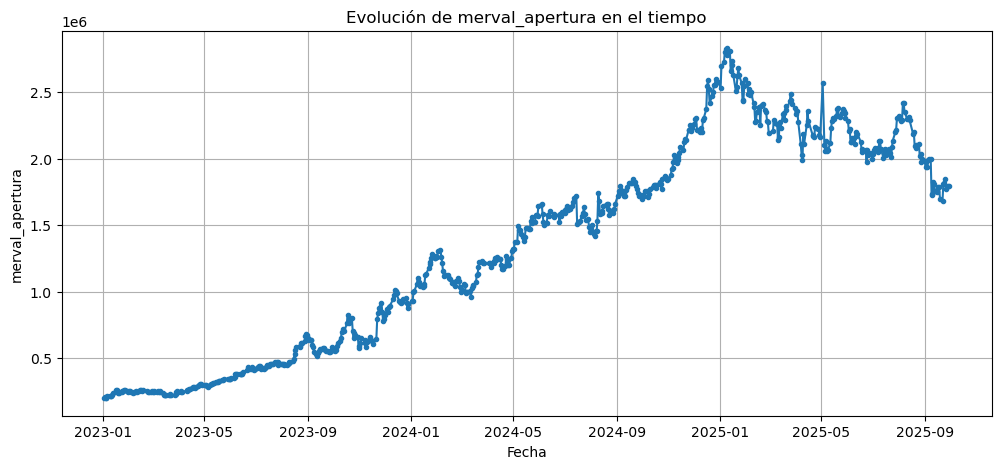

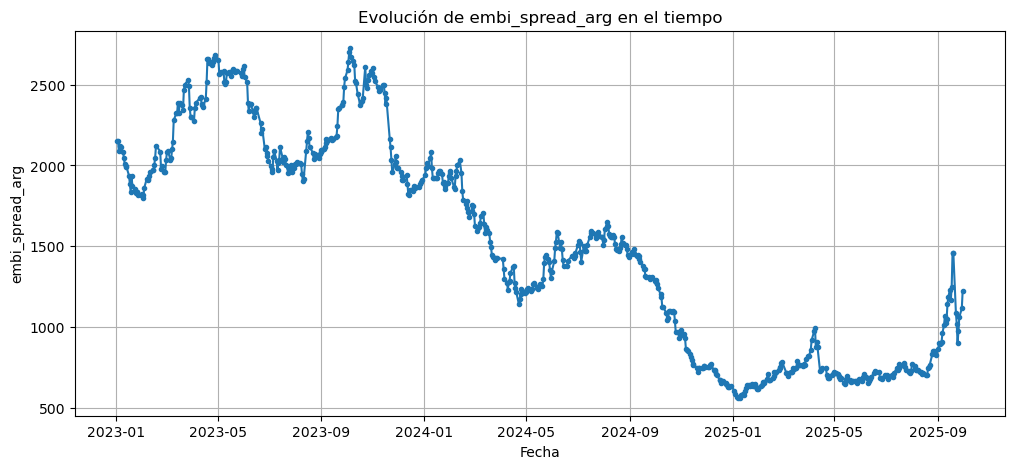

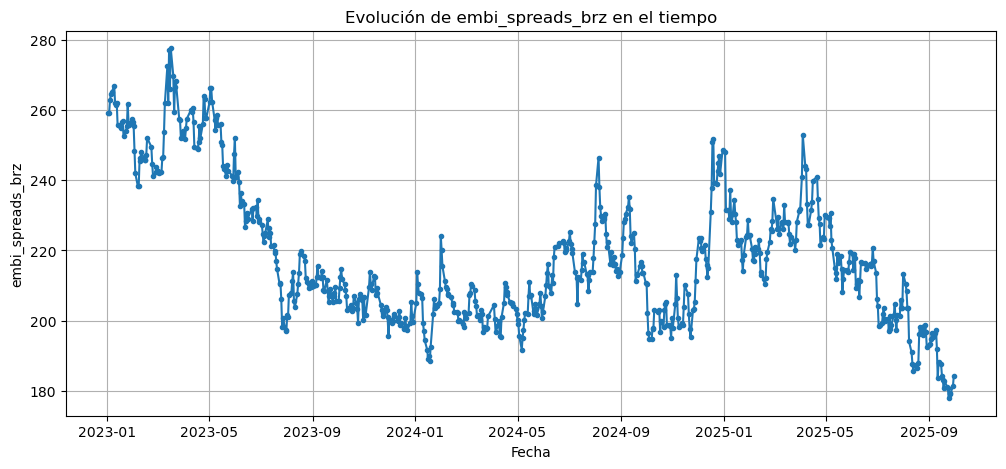

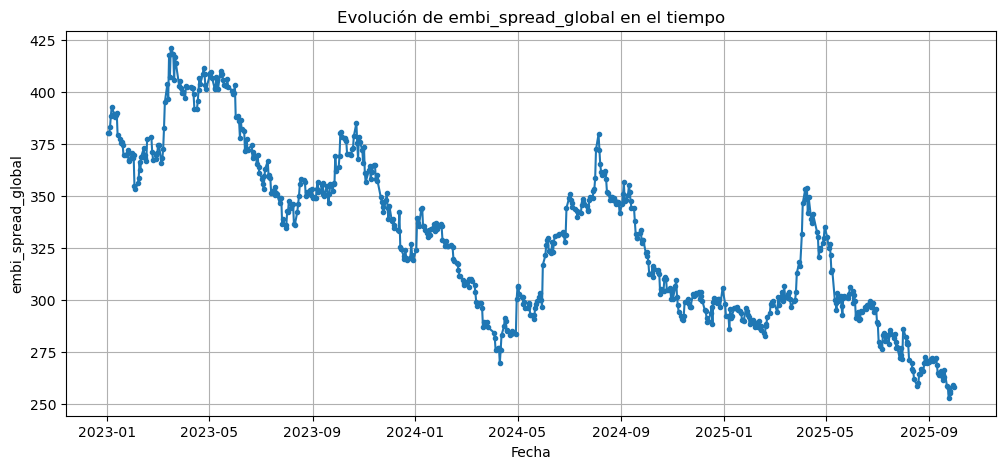

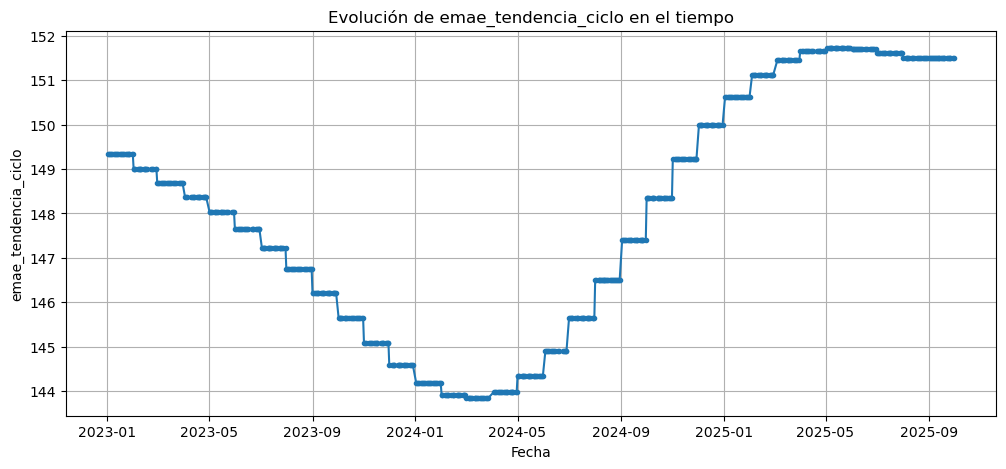

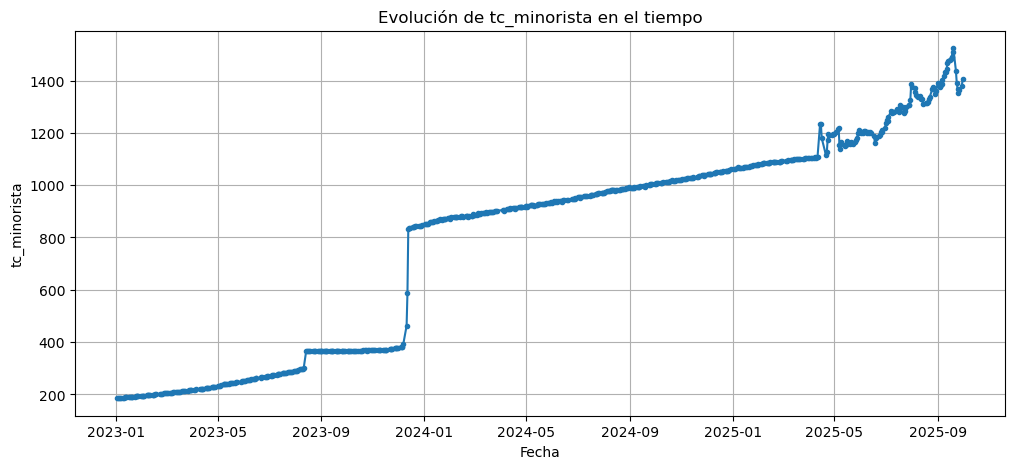

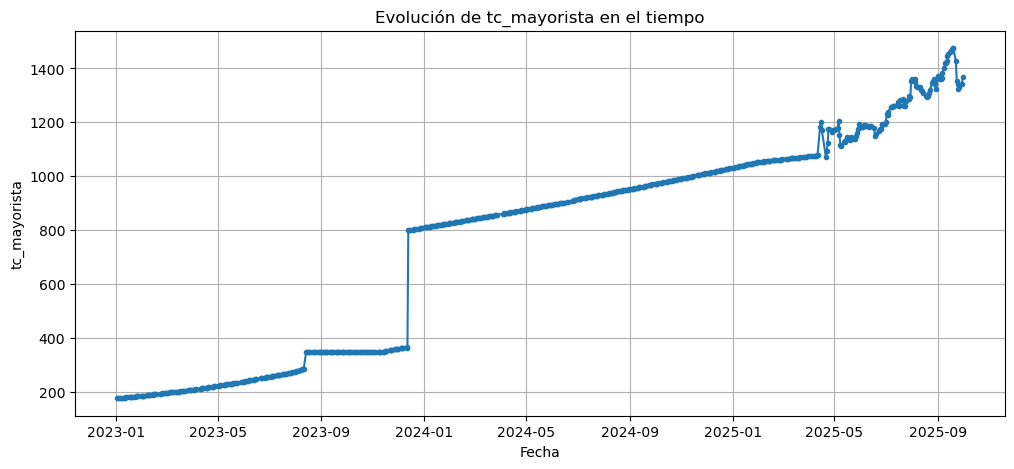

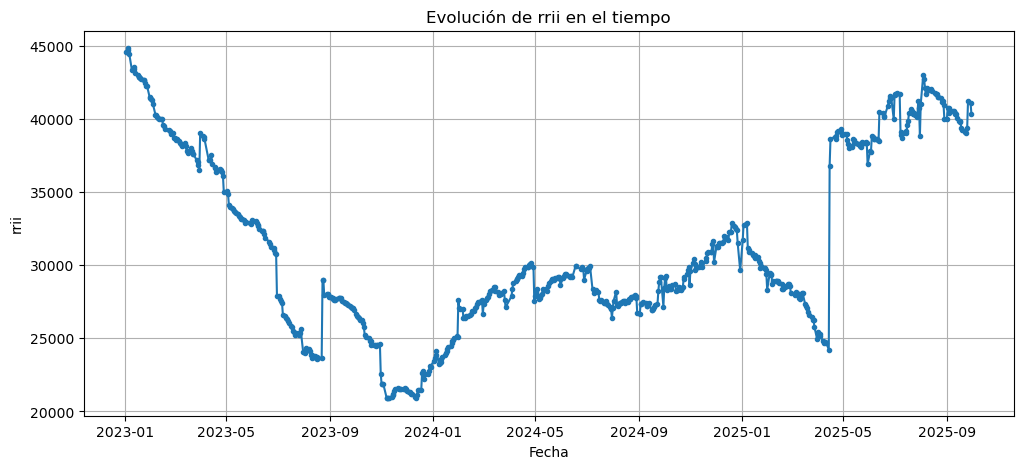

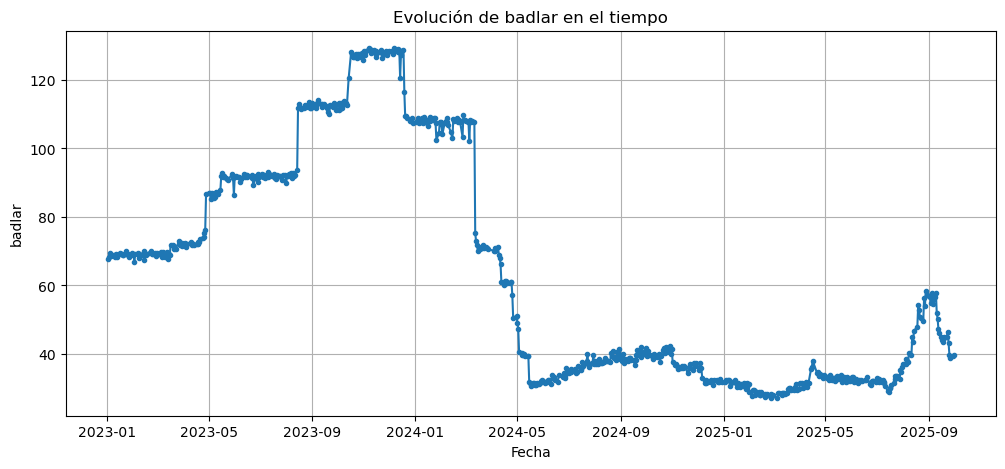

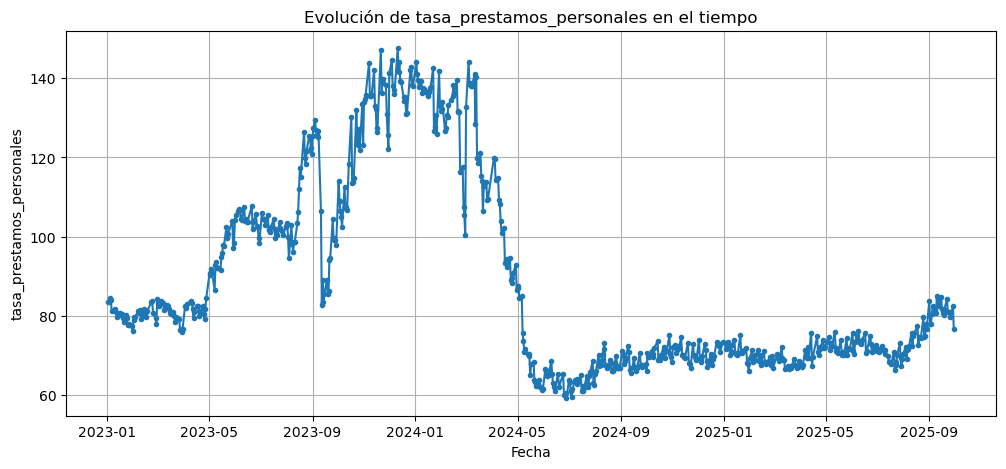

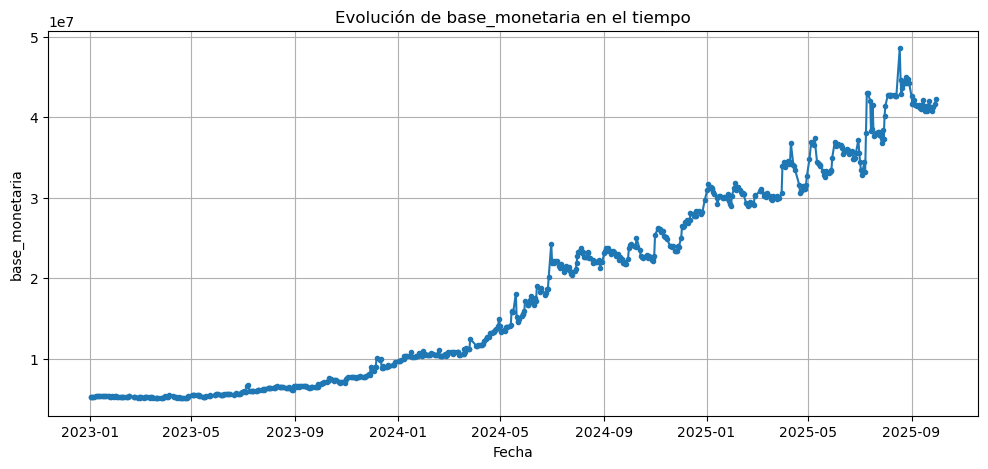

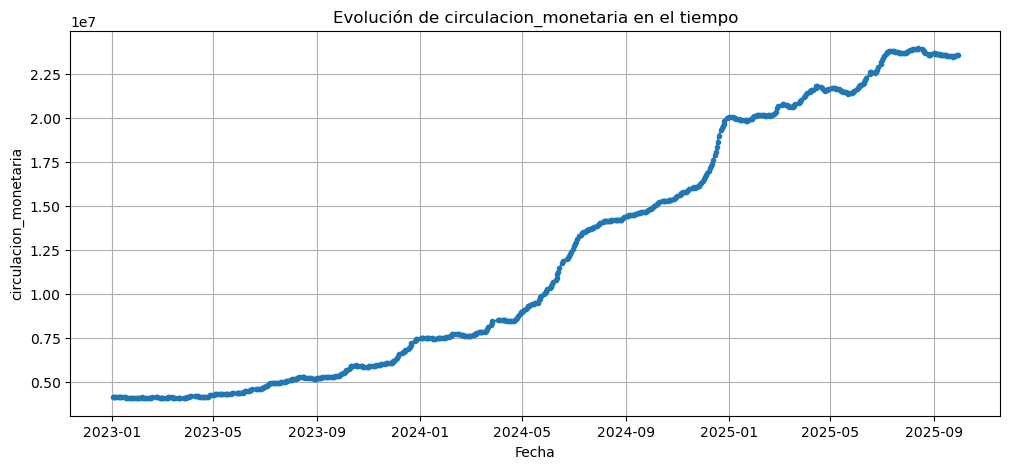

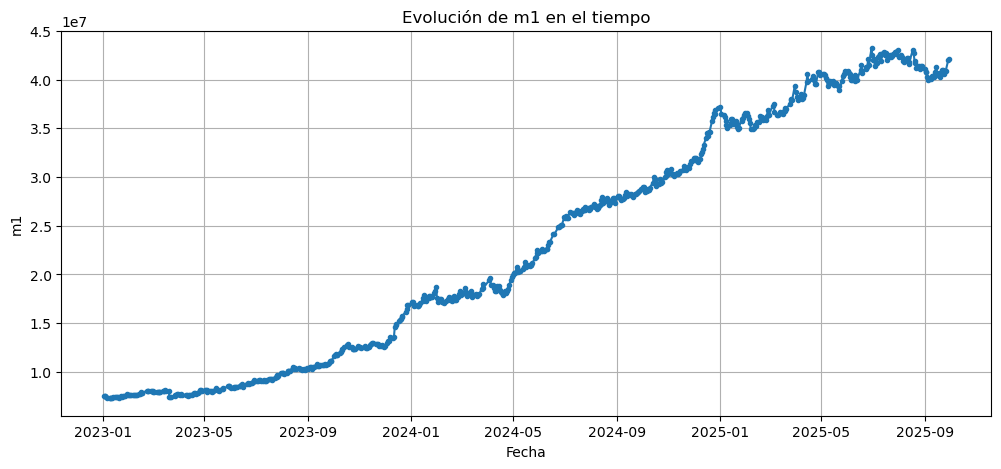

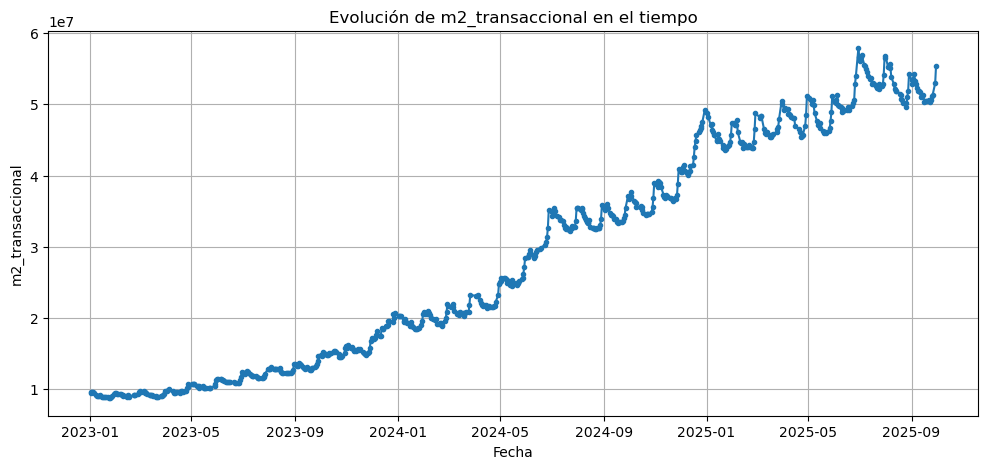

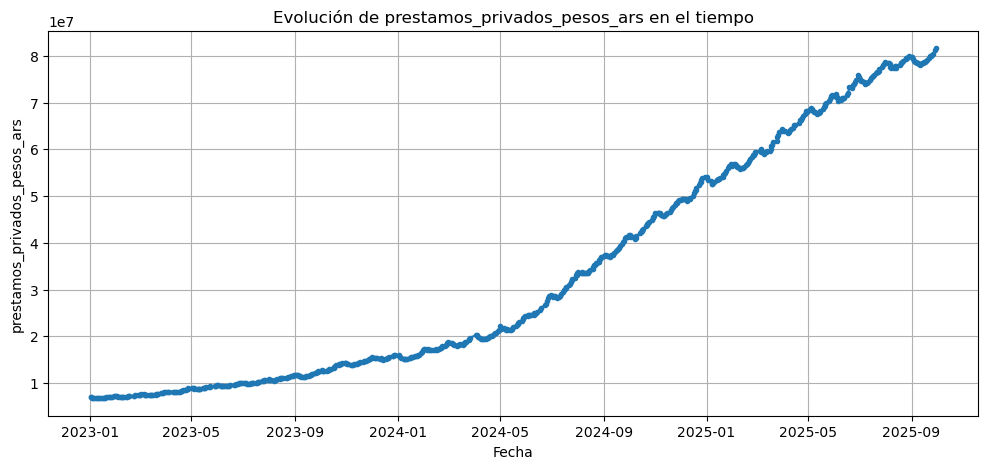

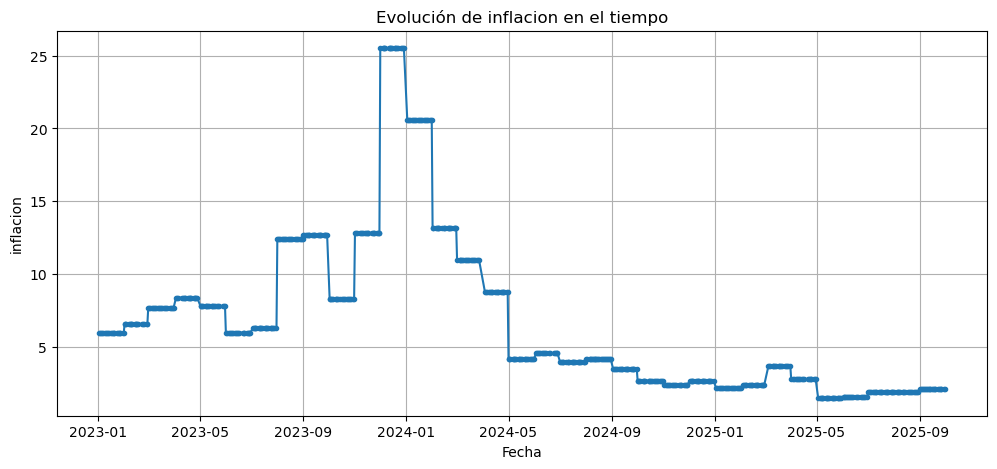

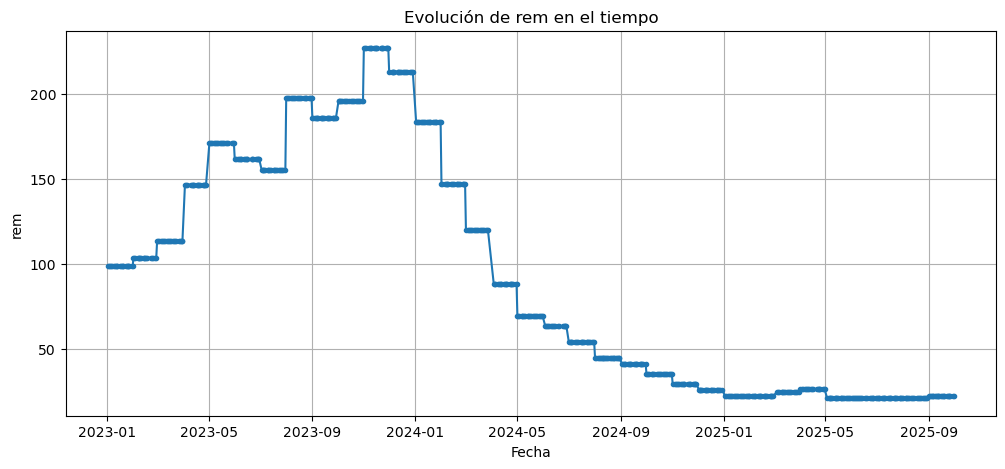

In [41]:
#3. Graficamos las columnas numéricas.
#a. Listamos las columnas numéricas (excluyendo 'fecha').
variables = series_temporales.drop(columns=["fecha"]).columns

#b. Graficamos cada variable en un gráfico separado.
for var in variables:
    plt.figure(figsize=(12,5))  # Nueva figura para cada variable
    plt.plot(series_temporales["fecha"], series_temporales[var], marker='.')
    plt.title(f"Evolución de {var} en el tiempo")
    plt.xlabel("Fecha")
    plt.ylabel(var)
    plt.grid(True)
    plt.show()

In [ ]:
#4. Primer análisis de la ST del Merval.
# A simple vista, parece vislumbrarse una tendencia general alcista, teniendo en cuenta la totalidad del período analizado. Este período comienza especialmente con las elecciones PASO, primera vuelta y ballotage que resulta como presidente Milei.
# Luego de un período lentamente ascendente desde 09/2023,se distinguen distintos ciclos de frecuencias más altas, pero que tampoco parecen ser mensuales ni de cierta temporalización común.
# También cabe destacar un período de gran pendiente alcista entre 10/2024 y 01/2025, momento donde la serie alcanza un pico máximo en principios del 2025, y una posterior tendencia bajista en los meses posteriores. Como hipótesis suponemos la existencia de algún evento económico y/o político puntual (corrupción? suba del dolar? elecciones bonarenses?).
# El final de esta serie, no está excepta de estos ciclos con picos locales y valles a sus costados. Aún más, parece apreciarse mayor volatilidad en el precio de apertura del Merval. 
# Además, durante toda la serie se puede observar cierto ruido de frecuencias altas, posiblemente a cambios semanales/diarios. Y la influencia de variables predictoras.

# Acompaña nuestra hipótesis que el Riesgo País tiene una tendencia bajista. Esto también se ve en el período posterior a 01/2025 donde, mientras el Merval desciende, el Riesgo País aumenta.
# Si analizamos el posible impacto del EMAE (actividad económica), podemos ver que desde Mayo/2024 se ve una tendencia a la recuperación, que se ve correspondida con los datos del Merval desfasados. Podemos decir que el Merval estaría "explicando" al EMAE. Cabe aclarar que este tipo de indicadores suelen tener una ventana temporal para verse su impacto, como así también podemos pensar que el Merval se anticipó a partir de las expectativas generadas sobre el EMAE.
# La mayor volatilidad (frecuencias más altas) que observamos a partir de 2025 también se observa en las series temporales del tipo de cambio minorista y mayorista. Sin dudas acá puede haber una explicación del fenómeno.
# Con respecto a las reservas internacionales, dede 01/2024 se puede vislumbrar una tendencia alcista de forma volatil. Dichos cambios no se ven reflejados en el precio de apertura del Merval.
# Respecto al contexto de base monetaria, circulación monetaria, y prestámos privados en pesos, hay una tendencia general alcista, con diferentes ciclos de distintas frecuencias al interior de cada una de las series aquí planteadas.
# También podemos ver una inflación mensual con una tendencia bajista, aunque con ciertos vaivenes propios de la economía doméstica. Este dato viene acompañado por una inflación esperada (rem) también bajista, lo que nos habla de las expectativas en esta materia.

#### F. Análisis en el Dominio de la Frecuencia (con TTF) y aplicación de filtros pasa-altos.

In [ ]:
#6. Calculamos la Transformada de Fourier (FFT).
#a. Hacemos una copia, y seteamos la Fecha como índice.
df = series_temporales.copy()
df['fecha'] = pd.to_datetime(df['fecha'])
df.set_index('fecha', inplace=True)

#b. Reindexamos para días de operación, y nos aseguramos que no haya nulos (igual, ya fue comprobado en pasos posteriores. Esto es una medida de seguridad adicional).
df = df.asfreq('D')  # frecuencia diaria
df['merval_apertura'] = df['merval_apertura'].fillna(method='ffill')

#c. FFT.
merval_values = df['merval_apertura'].values
N = len(merval_values)

# Transformada de Fourier
fft_vals = np.fft.fft(merval_values)

# Magnitud del espectro (sin normalización)
fft_magnitude = np.abs(fft_vals)

# Frecuencias
fft_freq = np.fft.fftfreq(N, d=1)

# Filtramos solo frecuencias positivas.
mask = fft_freq > 0
fft_freq = fft_freq[mask]
fft_magnitude = fft_magnitude[mask]

# Graficamos la serie original y FFT.
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(df.index, df['merval_apertura'], color='steelblue')
plt.title("Serie Temporal del Merval (Apertura)")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(fft_freq, fft_magnitude, color='darkgreen')
plt.title("FFT de Merval — Magnitud del Espectro")
plt.xlabel("Frecuencia [ciclos/día]")
plt.ylabel("Magnitud |FFT|")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# En el gráfico se pueden visualizar frecuencias muy bajas dado que la tendencia lineal alcista sostenida se está llevando toda la energía de la serie. Lógica que siguen naturalmente los mercados, en tanto se suelen mover a largo plazo. Por lo tanto, para visualizar los ciclos más pequeños, vamos a descomponer la serie. 
# Cabe destacar que aplicar medias móviles suavizaría la serie, lo que resaltaría la tendencia y eliminaría las variaciones de alta frecuencia. Lo cual es perjudicial en tanto nuestro objetivo es encontrar ciclos ocultos o patrones locales.

In [ ]:
#2. Quitamos la tendencia.
#a. Quitamos la tendencia lineal.
merval_detrended = signal.detrend(df['merval_apertura'].values)

#b. FFT sobre la serie sin tendencia.
fft_vals = np.fft.fft(merval_detrended)
fft_freq = np.fft.fftfreq(len(merval_detrended), d=1)
fft_magnitude = np.abs(fft_vals)

plt.figure(figsize=(12,5))
plt.plot(fft_freq[:len(fft_freq)//2], fft_magnitude[:len(fft_magnitude)//2])
plt.xlabel('Frecuencia [ciclos/día]')
plt.ylabel('Magnitud |FFT|')
plt.title('FFT del Merval — Serie Detrendida')
plt.grid(True)
plt.show()

In [ ]:
# Si bien se muestra mayor energía en frecuencias más altas, siguen siendo entre 0 y 0.1 (10 días). De hecho, en vez de analizar los precios absolutos, vamos a analizar rendimientos diarios.

In [ ]:
#3. Aplico un filtro FIR ----> Diferenciación para ver frecuencias más altas.
#a. Copio el DataFrame y preparo el índice.
df_destrend_diferenciacion = series_temporales.copy()
df_destrend_diferenciacion['fecha'] = pd.to_datetime(df_destrend_diferenciacion['fecha'])
df_destrend_diferenciacion.set_index('fecha', inplace=True)

#b. Diferenciación.
df_destrend_diferenciacion['diferenciada'] = df_destrend_diferenciacion['merval_apertura'].diff()

#c. Calculo FFT de la serie diferenciada.
serie_fft = df_destrend_diferenciacion['diferenciada'].dropna()
N = len(serie_fft)
yf = np.fft.fft(serie_fft)
xf = np.fft.fftfreq(N, d=1)

#d. Filtro solo frecuencias positivas.
mask = xf > 0
xf = xf[mask]
spectrum = np.abs(yf[mask])

#e. Grafico.
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(df_destrend_diferenciacion.index, df_destrend_diferenciacion['merval_apertura'], label='Original')
plt.title('Serie Original')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(df_destrend_diferenciacion.index[1:], df_destrend_diferenciacion['diferenciada'].dropna(), label='Diferenciada', color='orange')
plt.title('Serie Diferenciada (Retornos)')
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(xf, spectrum, color='green')
plt.title('FFT de la Serie Diferenciada (sin normalización)')
plt.xlabel('Frecuencia [ciclos/día]')
plt.ylabel('Magnitud')
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# En esta transformación de la serie temporal podemos ver diferencias de precios entre días. En este sentido, en la serie diferenciada podemos visualizar que esta serie temporal:

# - Oscila alrededor de cero, como se esperabamos tras quitar la tendencia.
# - Hay picos a mediados de 2024 y, especialmente, en mayo de 2025, lo que indica días con movimientos muy bruscos.
# - La mayoría de los valores son chicos, lo que sugiere que la serie es bastante estable salvo eventos puntuales.
# - La amplitud creciente se puede explicar por el aumento de los precios (inflación).

#- Si pasamos al dominio de la frecuencia de la serie diferenciada:
#- Vemos picos en diferentes frecuencias, especilamente entre 0.15 y 0.3 (entre 3 y 8 días, en  resumen, una semana financiera).
# - No hay una perioricidad fuerte (distinguible por un pico marcado).
#- Ahora bien, también puede ser ruido.

#### G. Analizo la autocorrelación de las ST --> Calcula la similaridad de una serie temporal consigo misma, a diferentes desplazamientos (o lags).
- Método para entender si tienen frecuencias altas o es "ruido".
- En caso de tener "ruido", puedo aplicar algún filtro "pasa bajos", para eliminarlo.
- ¿Cómo identificar el "ruido?
    * La ACF será prácticamente cero para todos los lags distintos de 0.
    * Solo se verá un pico en lag 0 y luego nada significativo (pequeñas fluctuaciones aleatorias alrededor de cero).
    * Si todos están dentro de los intervalos de confianza (normalmente ±1.96/√N), significa que no hay correlación significativa → mucho ruido.
    * Si algunos lags están fuera del intervalo de confianza, hay señal estructurada → menos ruido.
    * Justamente, que la única autocorrelación sea 0, significa que la serie temporal solo correlaciona consigo misma en 0. Osea, no hay tendencias. Es todo errático.

- Tip visual:
    * Un pico solo en lag 0 y todo lo demás casi en cero → ruido.
    * Picos periódicos o decrecientes → hay estructura (tendencia, estacionalidad, autocorrelación real).

In [ ]:
#1. Calculo autocorrelaciones con lags.
serie = series_temporales["merval_apertura"]
max_lags = min(30, len(serie)-1)  # lags no puede superar tamaño de la serie - 1.
if max_lags <= 0:
    print(f"No hay suficientes datos para merval_apertura")

plt.figure(figsize=(10,4))
plot_acf(serie, lags=max_lags)
plt.title(f"Autocorrelación de merval_apertura")
plt.xlabel("Lag")  # Etiqueta del eje X.
plt.ylabel("Autocorrelación")  # Etiqueta del eje Y.
plt.show()

In [ ]:
# Se ve una autocorrelación en todos los lagos. Posiblemnete se debe a la tendencia muy fuerte que tiene, donde todos los puntos correlacionan con los anteriores. Por eso, vamos a ver la serie diferenciada.

In [ ]:
#2. Serie diferenciada.
serie_diff = serie.diff().dropna()
plot_acf(serie_diff, lags=max_lags)
plt.title("Autocorrelación de merval_apertura (Diferenciada)")
plt.xlabel("Lag")  # Etiqueta del eje X.
plt.ylabel("Autocorrelación")  # Etiqueta del eje Y.
plt.show()

In [ ]:
# - Con excepción a lag 12, después de diferenciar, la serie parece estacionaria y no muestra autocorrelación significativa → comportamiento cercano a ruido blanco. Esto sin dudas atenta contra la intención de predecir el valor futuro del Merval.

#### H. Correlación de todas las ST respecto al precio del Merval.

In [ ]:
#5. Calculo correlación con el precio de apertura del Merval.
#a. Combinamos todas las series en un único DataFrame.
df = series_temporales.copy()

#b. Nos aseguramos que 'fecha' no esté en el DataFrame numérico.
if 'fecha' in df.columns:
    df = df.drop(columns=['fecha'])


#c. Alineo fechas y elimino filas con NA residuales.
df = df.dropna()

#d. Calculo correlación con merval_apertura.
#i. Correlación contemporánea (lag 0).
correlations = df.corr()['merval_apertura'].sort_values(ascending=False)
plt.figure(figsize=(10,6))
correlations.drop('merval_apertura').plot(kind='bar')
plt.title("Correlación contemporánea con merval_apertura")
plt.ylabel("Correlación")
plt.grid(True)
plt.show()

#ii. Cross-correlation con lags (!= 0).
lags = 30
for var in df.columns:
    if var == 'merval_apertura':
        continue
    cross_corr = [df['merval_apertura'].corr(df[var].shift(lag)) for lag in range(-lags, lags+1)]
    plt.figure(figsize=(12,4))
    plt.stem(range(-lags, lags+1), cross_corr)
    plt.title(f"Cross-correlation: {var} vs merval_apertura")
    plt.xlabel("Lag")
    plt.ylabel("Correlación")
    plt.grid(True)
    plt.show()

In [ ]:
#a. Riesgo País y Merval.
#- Todas las correlaciones son negativas y muy fuertes (≈ -0.85) en todos los lags. Esto significa que cuando el EMBI sube, el Merval tiende a bajar, y viceversa. Pero al no depender del lag, nos dice que EMBI y Merval se moverían simultáneamente (ambos responderían al mismo contexto macroeconómico). 
# En otras palabras, EMBI no “anticipa” al Merval ni viceversa.
# En conclusión, agregar variables con lags del Riesgo País no aportaría mucho. 

In [ ]:
#b. Actividad económica y BADIAR.
#- Podemos ver que ambas series están altamente correlacionadas. El pico está en lag -30 (~0.65) y va disminuyendo hacia lag +30. En otras palabras, cuando el MERVAL se mueve antes (lag negativo), la correlación con EMAE es más fuerte. Osea, parece anticipar la tendencia del EMAE. 
# Es decir, el mercado reacciona antes que la actividad económica. No nos serviría com predictor y no tendría sentido hacer lags.
#- Algo muy parecido sucede con el BADIAR.

In [ ]:
#c. Tipo de cambio, base monetaria, circulación monetaria y préstamos privados en pesos.
#- Se puede ver altas correlaciones positivas sin importar el lag. Esto nos habla nuevamente de que se moverían simultaneamente. Y que no tendría sentido hacer lags.
#- Algo parecido pasa con la base y circulación monetaria, y los prestamos privados en pesos.

In [ ]:
#d. Reservas Internacionales.
#- Existe una moderada correlación en los lags negativos, descendiendo a medida que se acerca a 0. En otras palabras, El MERVAL anticipa movimientos en reservas. 
# Osea, Las reservas no explican el comportamiento del MERVAL. Y no tiene sentido hacer lags.

In [ ]:
#e. Inflación y REM.
#- Se puede visualizar una correlación negativa fuerte en todos los lags. Esto indica que cuando el MERVAL sube, la inflación tiende a bajar, y viceversa.
#- Ahora bien, al no parecer ser una consecuencia de la otra (dado que la correlación es similar/constante en todos los lags, posiblemente por la imputación realizada), podemos pensar en que la inflación alta coincide con mercados deprimidos. Lo que nos habla más de la macroeconomía que del vínculo potencialmente explicativo de las variables en si.

# I. Conclusiones finales del trabajo exploratorio.

1. Serie Original.

Tiene una tendencia muy fuerte → no estacionaria.
ARIMA requiere estacionariedad, así que habría que diferenciarla (lo hicimos).
Pero la tendencia explica casi todo, y eso no es “predictivo” en el sentido de patrones repetitivos.


2. Serie Diferenciada.

ACF muestra casi ruido blanco (sin autocorrelación significativa).
FFT muestra picos débiles en frecuencias medias, pero no dominantes.
Esto indica que los retornos son poco predecibles → típico en mercados financieros.


3. Modelos de ML.
Si solo usamos la serie como input (sin features externas), el modelo verá ruido.
Para mejorar, necesitamos features adicionales:

* a- Indicadores técnicos (RSI, medias móviles, volatilidad).
* b- Variables macroeconómicas (inflación, tasas, EMBI).
* c- Sentimiento del mercado.

4. Variables a utilizar.
* a- EMAE, BADIAR, tipo de cambio, base monetaria, variables de circulación monetaria, préstamos privados en pesos, riesgo país nacional y global e inflación pero sin lags. Y teniendo en cuenta que algunas correlacionan negativamente, y otras positivamente.
* b- Las reservas internacionales claramente tienen correlación débil en lag 0, y recién aumenta para lags negativos (MERVAL explicaría RRII, y no al revés). Además, se podría descartar la variable respectiva del riesgo país de brasil, en representación del riesgo país regional, en tanto su correlación es débil.
* c- En total, quedarían 14 variables para predecir el Merval + los lags del Merval que se quieran construir.